In [1]:
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd
df_health = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print(df_health['Health_Indicator_Desc'].unique())

Saving chsp_2024_odp.csv to chsp_2024_odp.csv
['Deaths Due to All Causes' 'Deaths Due to All Cancers'
 'Deaths Due to Colorectal Cancer' 'Deaths Due to Lung Cancer'
 'Deaths Due to Female Breast Cancer' 'Deaths Due to Prostate Cancer'
 'Deaths Due to Diabetes' "Deaths Due to Alzheimer's Disease"
 'Deaths Due to Coronary Heart Disease'
 'Deaths Due to Cerebrovascular Disease (Stroke)'
 'Deaths Due to Influenza and Pneumonia'
 'Deaths Due to Chronic Lower Respiratory Disease'
 'Deaths Due to Chronic Liver Disease and Cirrhosis'
 'Deaths Due to Accidents (Unintentional Injuries)'
 'Deaths Due to Motor Vehicle Traffic Crashes' 'Deaths Due to Suicide'
 'Deaths Due to Homicide' 'Firearm Related Deaths' 'Drug Overdose Deaths'
 'Reported Prevalence of Persons Living with HIV/AIDS among Ages 13 Years and Older'
 'Reported Incidence of Chlamydia'
 'Reported Incidence of Gonorrhea among Females 15 to 44 Years Old'
 'Reported Incidence of Gonorrhea among Males 15 to 44 Years Old'
 'Reported Incide

In [2]:
!pip install pandasql scikit-learn

from google.colab import files
print("Upload expectedpayerpdd.csv")
uploaded1 = files.upload()

print("Upload chsp_2024_odp.csv")
uploaded2 = files.upload()

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=8f866877cac0fabd05be3d8b9a92c3bb09d9d9567f28f3beb54fcc38a5caaced
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
Upload expectedpayerpdd.csv


Saving expectedpayerpdd.csv to expectedpayerpdd.csv
Upload chsp_2024_odp.csv


Saving chsp_2024_odp.csv to chsp_2024_odp (1).csv


In [3]:
# Save both files
for name, data in uploaded1.items():
    pd.read_csv(io.BytesIO(data)).to_csv('expectedpayerpdd.csv', index=False)

for name, data in uploaded2.items():
    pd.read_csv(io.BytesIO(data)).to_csv('chsp_2024_odp.csv', index=False)

In [4]:
"""
California Hospital Medi-Cal Rate Prediction Model
Author: Michael Lee
Data Sources:
  1. HCAI Hospital Inpatient Characteristics by Patient County of Residence
     https://data.chhs.ca.gov/dataset/hospital-inpatient-characteristics-by-patient-county-of-residence
  2. CHSP County Health Status Profiles 2024
     https://data.chhs.ca.gov/dataset/county-health-status-profiles

This project builds a binary classification model to predict whether a
California county has a HIGH Medi-Cal utilization rate (above statewide
median) based on county-level demographic and health indicators.

Why this matters:
Counties with high Medi-Cal rates serve predominantly low-income populations
and face different financial pressures than counties with primarily private
insurance. Predicting which counties fall into the high Medi-Cal category
helps healthcare planners allocate resources and design targeted programs.

Machine Learning Pipeline:
1. Feature engineering from two public datasets
2. Binary classification target variable creation
3. Train/test split
4. Random Forest classifier
5. Model evaluation: accuracy, confusion matrix, ROC curve
6. Feature importance analysis
"""

import pandas as pd
import numpy as np
import pandasql as ps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 - LOAD AND PREPARE HOSPITAL DATA
# ============================================================

def load_hospital_data(filepath):
    """Load and normalize HCAI payer mix data."""
    print("Loading hospital payer mix data...")
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={
        'patcnty1': 'county',
        'dsch_yr': 'year',
        'pay_cat1': 'payer',
        'Discharges': 'discharges'
    })
    df = df[['county', 'year', 'payer', 'discharges']].copy()
    df['discharges'] = pd.to_numeric(df['discharges'], errors='coerce')
    df = df.dropna(subset=['discharges'])
    df['discharges'] = df['discharges'].astype(int)
    df = df[~df['county'].str.contains('California|Total|Statewide', na=False, case=False)]

    def normalize_payer(payer):
        if payer in ['Private Coverage', 'Private Health Insurance']:
            return 'Private Coverage'
        if payer in ['Self-Pay', 'Self-Pay or Uninsured']:
            return 'Self-Pay'
        if payer in ['Other Payer', 'All Other Payers', 'Other Indigent',
                     'Invalid', 'Invalid/Blank']:
            return 'Other'
        return payer

    df['payer'] = df['payer'].apply(normalize_payer)
    print(f"Hospital data loaded: {df['county'].nunique()} counties, years {df['year'].min()}-{df['year'].max()}")
    return df


def build_county_features_sql(hospital_data):
    """
    Use SQL to build county-level features from hospital data.
    Calculates payer rates and total volume for the most recent year.
    """
    most_recent = hospital_data['year'].max()
    print(f"\nBuilding county features using SQL for year {most_recent}...")

    query = f"""
    SELECT
        county,
        SUM(discharges) AS total_discharges,
        ROUND(
            100.0 * SUM(CASE WHEN payer = 'Medi-Cal' THEN discharges ELSE 0 END)
            / SUM(discharges), 2) AS medi_cal_pct,
        ROUND(
            100.0 * SUM(CASE WHEN payer = 'Medicare' THEN discharges ELSE 0 END)
            / SUM(discharges), 2) AS medicare_pct,
        ROUND(
            100.0 * SUM(CASE WHEN payer = 'Private Coverage' THEN discharges ELSE 0 END)
            / SUM(discharges), 2) AS private_pct,
        ROUND(
            100.0 * SUM(CASE WHEN payer = 'Self-Pay' THEN discharges ELSE 0 END)
            / SUM(discharges), 2) AS self_pay_pct,
        ROUND(
            100.0 * SUM(CASE WHEN payer = 'Other Government' THEN discharges ELSE 0 END)
            / SUM(discharges), 2) AS govt_pct
    FROM hospital_data
    WHERE year = {most_recent}
    GROUP BY county
    HAVING SUM(discharges) > 100
    ORDER BY medi_cal_pct DESC
    """
    features = ps.sqldf(query, {'hospital_data': hospital_data})
    print(f"County features built for {len(features)} counties")
    return features


# ============================================================
# STEP 2 - LOAD AND PREPARE HEALTH STATUS DATA
# ============================================================

def load_health_data(filepath):
    """
    Load CHSP County Health Status Profiles.
    Extract child poverty rate as a demographic feature.
    """
    print("\nLoading county health status data...")
    df = pd.read_csv(filepath, low_memory=False)

    # Filter to child poverty indicator
    poverty = df[
        (df['Health_Indicator_Desc'] == 'Persons under 18 Years Old in Poverty') &
        (df['Strata_Name'] == 'Total Population')
    ][['County', 'Rate/Percentage']].copy()

    poverty.columns = ['county', 'child_poverty_rate']
    poverty['child_poverty_rate'] = pd.to_numeric(
        poverty['child_poverty_rate'], errors='coerce'
    )
    poverty = poverty.dropna(subset=['child_poverty_rate'])

    # Clean county names to match hospital data
    poverty['county'] = poverty['county'].str.replace(' County', '').str.strip()

    print(f"Health data loaded: {len(poverty)} counties with poverty data")
    return poverty


# ============================================================
# STEP 3 - MERGE DATASETS AND CREATE TARGET VARIABLE
# ============================================================

def build_model_dataset(county_features, poverty_data):
    """
    Merge hospital features with poverty data.
    Create binary target: 1 = high Medi-Cal county, 0 = low Medi-Cal county.
    High is defined as above the statewide median Medi-Cal rate.
    """
    print("\nMerging datasets...")
    merged = county_features.merge(poverty_data, on='county', how='inner')

    # Create binary target variable
    median_medi_cal = merged['medi_cal_pct'].median()
    merged['high_medi_cal'] = (merged['medi_cal_pct'] > median_medi_cal).astype(int)

    print(f"Merged dataset: {len(merged)} counties")
    print(f"Statewide median Medi-Cal rate: {median_medi_cal:.1f}%")
    print(f"High Medi-Cal counties: {merged['high_medi_cal'].sum()}")
    print(f"Low Medi-Cal counties: {(merged['high_medi_cal'] == 0).sum()}")
    return merged, median_medi_cal


# ============================================================
# STEP 4 - TRAIN MODEL
# ============================================================

def train_model(df):
    """
    Train a Random Forest classifier to predict high Medi-Cal counties.

    Features:
    - child_poverty_rate: % of children under 18 in poverty
    - self_pay_pct: % of discharges paid out of pocket (uninsured)
    - medicare_pct: % of discharges covered by Medicare
    - private_pct: % of discharges with private insurance
    - govt_pct: % of discharges with other government coverage
    - total_discharges: total hospital volume

    Target: high_medi_cal (1 = above median, 0 = below median)
    """
    print("\nTraining Random Forest classifier...")

    features = [
        'child_poverty_rate',
        'self_pay_pct',
        'medicare_pct',
        'private_pct',
        'govt_pct',
        'total_discharges'
    ]

    X = df[features]
    y = df['high_medi_cal']

    # Train/test split - 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Training set: {len(X_train)} counties")
    print(f"Test set: {len(X_test)} counties")

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Cross-validation score
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"\nCross-validation accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

    # Test set predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"Test set accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Low Medi-Cal', 'High Medi-Cal']))

    return model, X_train, X_test, y_train, y_test, y_pred, y_prob, features


# ============================================================
# STEP 5 - VISUALIZE RESULTS
# ============================================================

def create_model_visualizations(model, df, X_test, y_test, y_pred,
                                 y_prob, features, median_medi_cal):
    """
    Four-panel visualization of model results:
    1. Feature importance
    2. Confusion matrix
    3. ROC curve
    4. Actual Medi-Cal rates by county with prediction overlay
    """
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(
        'California Hospital Medi-Cal Rate Prediction Model\n'
        'Random Forest Classifier — County-Level Analysis',
        fontsize=16, fontweight='bold', y=0.98
    )

    gs = gridspec.GridSpec(2, 2, figure=fig)

    # ---- PANEL 1: Feature Importance ----
    ax1 = fig.add_subplot(gs[0, 0])
    importances = model.feature_importances_
    feature_labels = [
        'Child Poverty Rate',
        'Self-Pay Rate',
        'Medicare Rate',
        'Private Coverage Rate',
        'Govt Coverage Rate',
        'Total Discharges'
    ]
    sorted_idx = np.argsort(importances)
    colors = ['#1565C0' if importances[i] == max(importances) else '#90CAF9'
              for i in sorted_idx]
    ax1.barh(
        [feature_labels[i] for i in sorted_idx],
        importances[sorted_idx],
        color=colors,
        edgecolor='white'
    )
    ax1.set_xlabel('Feature Importance', fontsize=10)
    ax1.set_title('Feature Importance\n(What drives Medi-Cal rates?)',
                  fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # ---- PANEL 2: Confusion Matrix ----
    ax2 = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_test, y_pred)
    im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
    ax2.set_title('Confusion Matrix\n(Test Set Predictions)',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=10)
    ax2.set_ylabel('True Label', fontsize=10)
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['Low Medi-Cal', 'High Medi-Cal'])
    ax2.set_yticklabels(['Low Medi-Cal', 'High Medi-Cal'])
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

    # ---- PANEL 3: ROC Curve ----
    ax3 = fig.add_subplot(gs[1, 0])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color='#1565C0', linewidth=2,
             label=f'ROC Curve (AUC = {roc_auc:.2f})')
    ax3.plot([0, 1], [0, 1], color='gray', linestyle='--',
             linewidth=1, label='Random Classifier')
    ax3.set_xlabel('False Positive Rate', fontsize=10)
    ax3.set_ylabel('True Positive Rate', fontsize=10)
    ax3.set_title('ROC Curve\n(Model Discrimination Ability)',
                  fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

    # ---- PANEL 4: County Medi-Cal Rates with Median Line ----
    ax4 = fig.add_subplot(gs[1, 1])
    df_sorted = df.sort_values('medi_cal_pct', ascending=True)
    colors4 = ['#C62828' if v == 1 else '#1565C0'
               for v in df_sorted['high_medi_cal']]
    ax4.barh(
        df_sorted['county'],
        df_sorted['medi_cal_pct'],
        color=colors4,
        edgecolor='white',
        linewidth=0.3
    )
    ax4.axvline(x=median_medi_cal, color='black', linestyle='--',
                linewidth=1.5, label=f'Median ({median_medi_cal:.1f}%)')
    ax4.set_xlabel('Medi-Cal % of Total Discharges', fontsize=10)
    ax4.set_title('Medi-Cal Rate by County\n(Red = High, Blue = Low)',
                  fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.tick_params(axis='y', labelsize=7)
    ax4.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('medi_cal_prediction_model.png', dpi=150, bbox_inches='tight')
    print("\nFigure saved as medi_cal_prediction_model.png")
    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    print("=" * 60)
    print("California Hospital Medi-Cal Rate Prediction Model")
    print("Random Forest Binary Classification")
    print("=" * 60)

    # Load data
    hospital_data = load_hospital_data('expectedpayerpdd.csv')
    county_features = build_county_features_sql(hospital_data)
    poverty_data = load_health_data('chsp_2024_odp.csv')

    # Build dataset
    df, median_medi_cal = build_model_dataset(county_features, poverty_data)

    # Train model
    model, X_train, X_test, y_train, y_test, y_pred, y_prob, features = train_model(df)

    # Visualize
    print("\nGenerating visualizations...")
    create_model_visualizations(
        model, df, X_test, y_test, y_pred,
        y_prob, features, median_medi_cal
    )

    # Show county predictions
    print("\n--- County Predictions ---")
    df['predicted_high_medi_cal'] = model.predict(df[features])
    df['correct'] = (df['high_medi_cal'] == df['predicted_high_medi_cal']).astype(int)
    print(df[['county', 'medi_cal_pct', 'child_poverty_rate',
              'high_medi_cal', 'predicted_high_medi_cal', 'correct']]
          .sort_values('medi_cal_pct', ascending=False)
          .to_string(index=False))

    print(f"\nOverall accuracy on full dataset: {df['correct'].mean():.2f}")
    print("\nDone.")


if __name__ == '__main__':
    main()

California Hospital Medi-Cal Rate Prediction Model
Random Forest Binary Classification
Loading hospital payer mix data...
Hospital data loaded: 60 counties, years 2012-2024

Building county features using SQL for year 2024...
County features built for 59 counties

Loading county health status data...
Health data loaded: 0 counties with poverty data

Merging datasets...
Merged dataset: 0 counties
Statewide median Medi-Cal rate: nan%
High Medi-Cal counties: 0
Low Medi-Cal counties: 0

Training Random Forest classifier...


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [5]:
import pandas as pd

df_health = pd.read_csv('chsp_2024_odp.csv', low_memory=False)

# Check what the poverty indicator rows look like
poverty_rows = df_health[
    df_health['Health_Indicator_Desc'] == 'Persons under 18 Years Old in Poverty'
]
print(f"Poverty rows found: {len(poverty_rows)}")
print("\nSample county names:")
print(poverty_rows['County'].head(10).tolist())
print("\nSample Strata_Name values:")
print(poverty_rows['Strata_Name'].unique())

Poverty rows found: 59

Sample county names:
['San Mateo', 'Placer', 'Santa Clara', 'Marin', 'Alameda', 'Napa', 'Sonoma', 'El Dorado', 'Orange', 'San Benito']

Sample Strata_Name values:
['Under 18 Years Old']


Loading hospital payer mix data...
Hospital data loaded: 60 counties, years 2012-2024

Building county features using SQL for year 2024...
County features built for 59 counties
Health data loaded: 59 counties

Merging datasets...
Merged dataset: 57 counties
Statewide median Medi-Cal rate: 28.0%
High Medi-Cal counties: 28
Low Medi-Cal counties: 29
Merged dataset: 57 counties

Training Random Forest classifier...
Training set: 45 counties
Test set: 12 counties

Cross-validation accuracy: 0.91 (+/- 0.06)
Test set accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

 Low Medi-Cal       0.83      0.83      0.83         6
High Medi-Cal       0.83      0.83      0.83         6

     accuracy                           0.83        12
    macro avg       0.83      0.83      0.83        12
 weighted avg       0.83      0.83      0.83        12


Figure saved as medi_cal_prediction_model.png


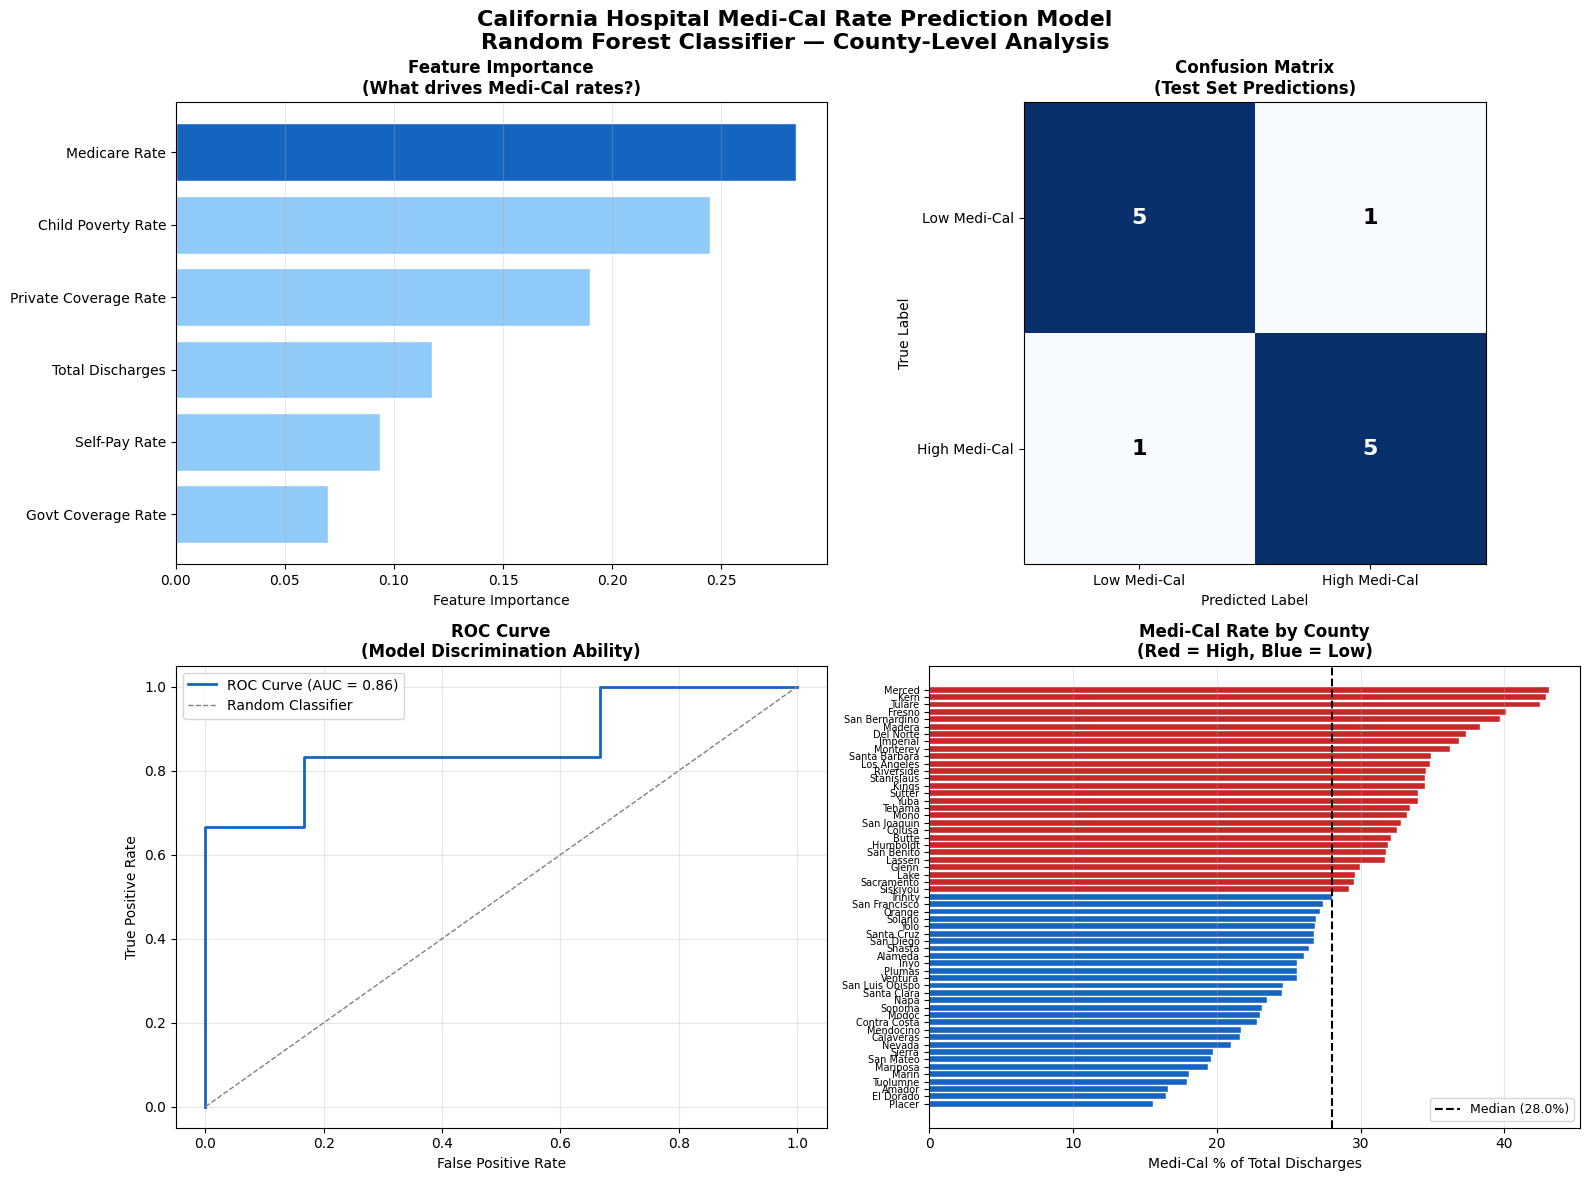

         county  medi_cal_pct  child_poverty_rate  high_medi_cal  predicted_high_medi_cal  correct
         Merced         43.11                28.8              1                        1        1
           Kern         42.89                25.3              1                        1        1
         Tulare         42.46                24.4              1                        1        1
         Fresno         40.14                26.8              1                        1        1
 San Bernardino         39.69                17.1              1                        1        1
         Madera         38.30                27.7              1                        1        1
      Del Norte         37.31                27.2              1                        1        1
       Imperial         36.84                21.6              1                        1        1
       Monterey         36.19                15.5              1                        1        1
  Santa Ba

In [7]:
# Step 1 - Reload hospital data
hospital_data = load_hospital_data('expectedpayerpdd.csv')
county_features = build_county_features_sql(hospital_data)

# Step 2 - Load fixed health data
def load_health_data_fixed(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    poverty = df[
        df['Health_Indicator_Desc'] == 'Persons under 18 Years Old in Poverty'
    ][['County', 'Rate/Percentage']].copy()
    poverty.columns = ['county', 'child_poverty_rate']
    poverty['child_poverty_rate'] = pd.to_numeric(poverty['child_poverty_rate'], errors='coerce')
    poverty = poverty.dropna(subset=['child_poverty_rate'])
    poverty['county'] = poverty['county'].str.strip()
    print(f"Health data loaded: {len(poverty)} counties")
    return poverty

poverty_data = load_health_data_fixed('chsp_2024_odp.csv')

# Step 3 - Merge and build target
df, median_medi_cal = build_model_dataset(county_features, poverty_data)
print(f"Merged dataset: {len(df)} counties")

# Step 4 - Train model
model, X_train, X_test, y_train, y_test, y_pred, y_prob, features = train_model(df)

# Step 5 - Visualize
create_model_visualizations(
    model, df, X_test, y_test, y_pred,
    y_prob, features, median_medi_cal
)

# Step 6 - County predictions table
df['predicted_high_medi_cal'] = model.predict(df[features])
df['correct'] = (df['high_medi_cal'] == df['predicted_high_medi_cal']).astype(int)
print(df[['county', 'medi_cal_pct', 'child_poverty_rate',
          'high_medi_cal', 'predicted_high_medi_cal', 'correct']]
      .sort_values('medi_cal_pct', ascending=False)
      .to_string(index=False))
print(f"\nOverall accuracy: {df['correct'].mean():.2f}")

In [8]:
from google.colab import files
files.download('medi_cal_prediction_model.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>